In [1]:

import os
import sys
# sys.path.append(os.path.dirname(os.path.dirname(__file__)))
sys.path.append('/home/scc_e_393956/ncc/rsa/')
from configs.config2 import * # directories + constants

import mne
import matplotlib
import numpy as np
from attrs import define
from pyrasa.irasa import irasa
from pyrasa.utils.peak_utils import get_band_info
from scipy.stats import zscore


from utils import raw
from utils.ica import get_outFilePaths, get_blockwise_outFilePaths
from utils.subj import get_MEG_raw_subjects
import subprocess
from pathlib import Path

os.environ["MNE_BROWSER_BACKEND"] = "matplotlib"
mne.viz.set_browser_backend("matplotlib")

# %matplotlib widget
import matplotlib.pyplot as plt
import mne
%matplotlib widget
# mne.set_config("MNE_BROWSER_BACKEND", "matplotlib")
# mne.set_config("MNE_BROWSE_RAW_SIZE", "6,1")
# mne.set_config("MNE_BROWSE_RAW_SCALE", "0.5")

Using matplotlib as 2D backend.


In [2]:
def find_train_ica(
	raw: mne.io.Raw,
	ica: mne.preprocessing.ICA,
	train_freq: int,
	duration: int = 4,
	overlap: float = 0.5,
	hmax: float = 2,
	sd: float = 2,
) -> list:
	"""
	Detect ICA components associated with train artifacts in MEG data.

	Parameters
	----------
	raw : mne.io.Raw
		The raw MEG data used during ICA fitting.
	ica : mne.preprocessing.ICA
		The ICA object containing the decomposition results.
	train_freq : int
		The target frequency of the train artifact (e.g., 16 Hz).
	duration : int, optional
		Window duration (in seconds) for PSD computation. Defaults to 4.
	overlap : float, optional
		Overlap ratio for PSD computation windows. Defaults to 0.5.
	hmax : float, optional
		Maximum up/downsampling factor for IRASA. Defaults to 2.
	sd : float, optional
		Standard deviation threshold for peak power detection. Defaults to 2.

	Returns
	-------
	list
		List of ICA component indices associated with train artifacts.
	"""

	# we add a small value to the hmax to be absolutely sure i am not going into filters
	# choice is pretty arbitrary we just want to absolutely avoid runnning into errors and
	# the artifact of interest is usually not on the borders of the spectrum.
	hmax_filt = hmax + 0.5

	# get info for train timeseries
	ic_signal = ica.get_sources(raw).get_data()

	# run irasa
	fs = raw.info['sfreq']

	lower, upper = raw.info['highpass'] / hmax_filt, raw.info['lowpass'] / hmax_filt

	irasa_out = irasa(
		ic_signal,
		fs=fs,
		band=(lower, upper),
		nperseg=int(duration * fs),
		noverlap=int(duration * fs * overlap),
		hset_info=(1, hmax, 0.05),
	)
	

	train_peaks = get_band_info(
		irasa_out.get_peaks(), freq_range=(train_freq - 1, train_freq + 1), ch_names=list(np.arange(ic_signal.shape[0]))
	).dropna()

	# print(train_peaks)
	# select the right number of components based on a thresholding procedure
	bad_ics = []
	if train_peaks.shape[0] > 1:
		while (zscore(train_peaks['pw']) > sd).sum() > 0:
			bad_ch = train_peaks[zscore(train_peaks['pw']) > sd]['ch_name'].values
			bad_ics.append(bad_ch)
			train_peaks = train_peaks.query(f'ch_name not in {list(bad_ch)}')
		# ------------------------------------------------------------------------- added by me:
		if not bad_ics:
			while not bad_ics:
				sd = sd-0.01
				print('trying lower sd:' , sd)
				while (zscore(train_peaks['pw']) > sd).sum() > 0:
					bad_ch = train_peaks[zscore(train_peaks['pw']) > sd]['ch_name'].values
					bad_ics.append(bad_ch)
					train_peaks = train_peaks.query(f'ch_name not in {list(bad_ch)}')
		# ------------------------------------------------------------------------- 
	else:
		bad_ics.append(train_peaks['ch_name'].values)

	if len(bad_ics) > 0:
		bad_ics = [int(val) for val in np.concatenate(bad_ics)]

	return train_peaks, irasa_out, bad_ics

open folder with rejected comp files no the side

In [3]:
# ica_folder = 'ica_qc_099cmp'
# ica_folder = 'ica_qc_095cmp'
ica_folder = 'ica_qc_blockwise2'
# ica_folder = 'ica_qc_095_Infomax'
folder_rejectedComps = f'/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/step3_rejected_comps'
folder_topoPlots = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/step3_comps_topos"
# folder_rejectedComps = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/old_step3_rejected_comps"
# folder_topoPlots = f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}/old_step3_comps_topos"

subprocess.Popen(["code", "--new-window", folder_rejectedComps])
subprocess.Popen(["code", "--new-window", folder_topoPlots])
plt.close('all')

In [4]:
# block-wise subjects
all_subjects = [
 '19970302urmr',
 '19910703eigl',
 '19840930bigs',
 '20031022ekse']

blockNames =  [	
				'block_01',
				'block_02',
				'block_03',
				'block_04',
				'block_05',
				'block_06',
				'block_07',
				'block_08',
				'block_09',
				'block_10',
				'block_11',
				'block_12',
	 ]

load data

## all_blocks

Subject ID: 19951227eipo
Opening raw data file /home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step2_ica_tmp_data/19951227eipo_ica_data.fif...
    Range : 14707 ... 1266955 =     73.535 ...  6334.775 secs
Ready.


/tmp/ipykernel_1480260/1843084610.py:19: RuntimeWarning: This filename (/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step2_ica_tmp_data/19951227eipo_ica_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(rawFile, preload=False)


Reading /home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc2/step2_ica_comps/19951227eipo_ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=53, n_times=1252249
    Range : 14707 ... 1266955 =     73.535 ...  6334.775 secs
Ready.


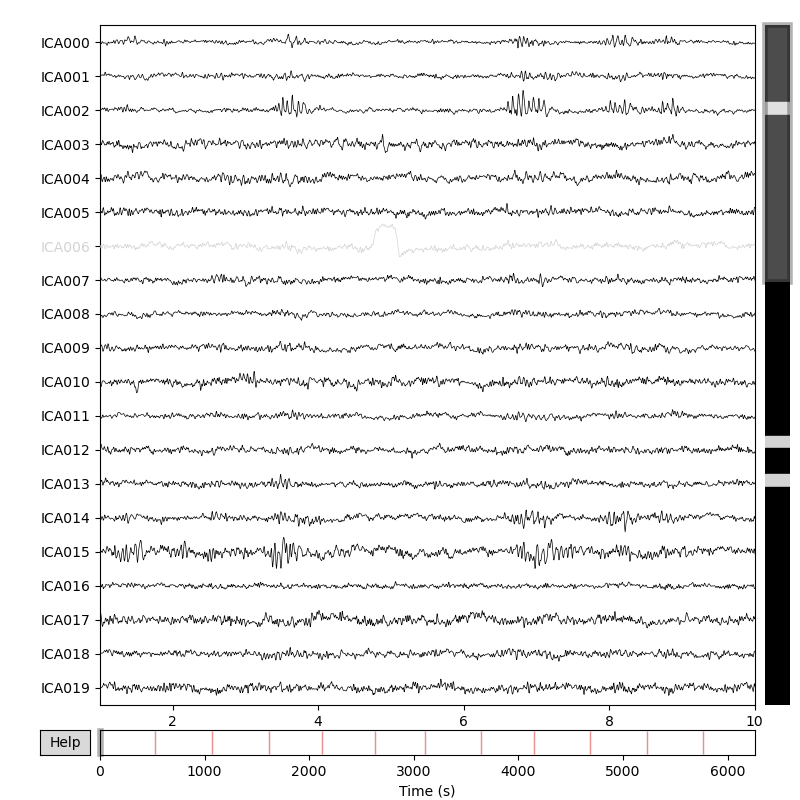

In [ ]:
subjNr = 0
blockNr = 1
ica_folder = 'ica_qc2'

plt.close('all')

blockNr = blockNr -1
# subject_id = all_subjects[all_subjects.index('19880331igse')]
# subject_id = all_subjects[30]
# subject_id = all_subjects[subjNr]
subject_id = '19951227eipo'
print(f"Subject ID: {subject_id}")

_, icaPaths = get_outFilePaths(subject_id, out_root=f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}")

rawFile = icaPaths['file_icaData']
icaFile = icaPaths['file_ica']

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
# raw = raw.filter(l_freq = None , h_freq=40.0, n_jobs=-1)
fig = ica.plot_sources(
    raw,
    show=True,
    block=False,
	overview_mode=False,
    start = 1,
    stop = 10,   
)


In [ ]:
train_peaks, irasa_out, bad_ics  = find_train_ica(raw, ica, train_freq = 16.7, sd = 1.5, hmax = 1.5) #, duration=4, overlap=0.7)
print(bad_ics)


[16, 27, 49]


In [123]:
print(zscore(train_peaks['pw']))

[ 1.42779181 -0.9369256   0.24971168  0.56432253 -1.30490042]


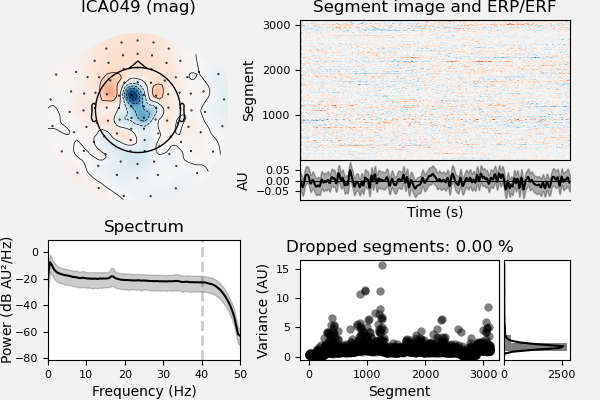

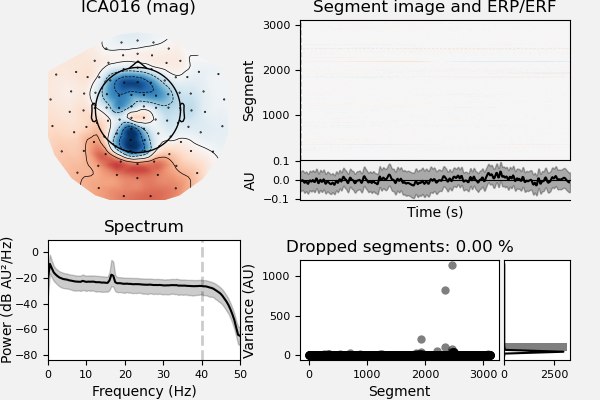

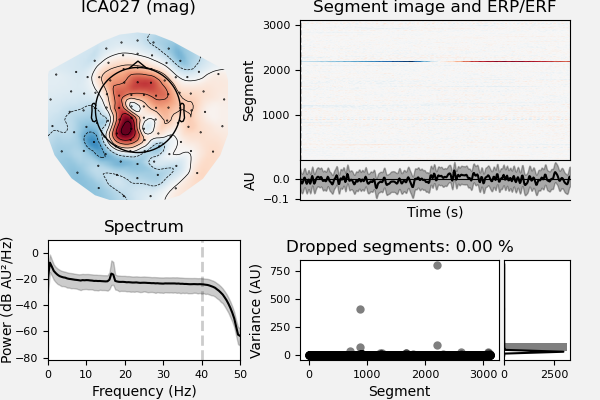

In [132]:
with mne.use_log_level('ERROR'):  # only show critical errors
	a = ica.plot_properties(
		raw, picks = [16, 27, 49],
		figsize = (6, 4), psd_args={'method': 'welch'})

## block-wise

Subject ID: 20040630gbaf
Opening raw data file /home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc_blockwise2/step2_ica_tmp_data/20040630gbaf_block_01_ica_data.fif...


/tmp/ipykernel_2799195/3100418716.py:27: RuntimeWarning: This filename (/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc_blockwise2/step2_ica_tmp_data/20040630gbaf_block_01_ica_data.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(rawFile, preload=False)


    Range : 26173 ... 126322 =    130.865 ...   631.610 secs
Ready.
Reading /home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc_blockwise2/step2_ica_comps/20040630gbaf_block_01_ica.fif ...
Now restoring ICA solution ...
Ready.
Creating RawArray with float64 data, n_channels=53, n_times=100150
    Range : 26173 ... 126322 =    130.865 ...   631.610 secs
Ready.


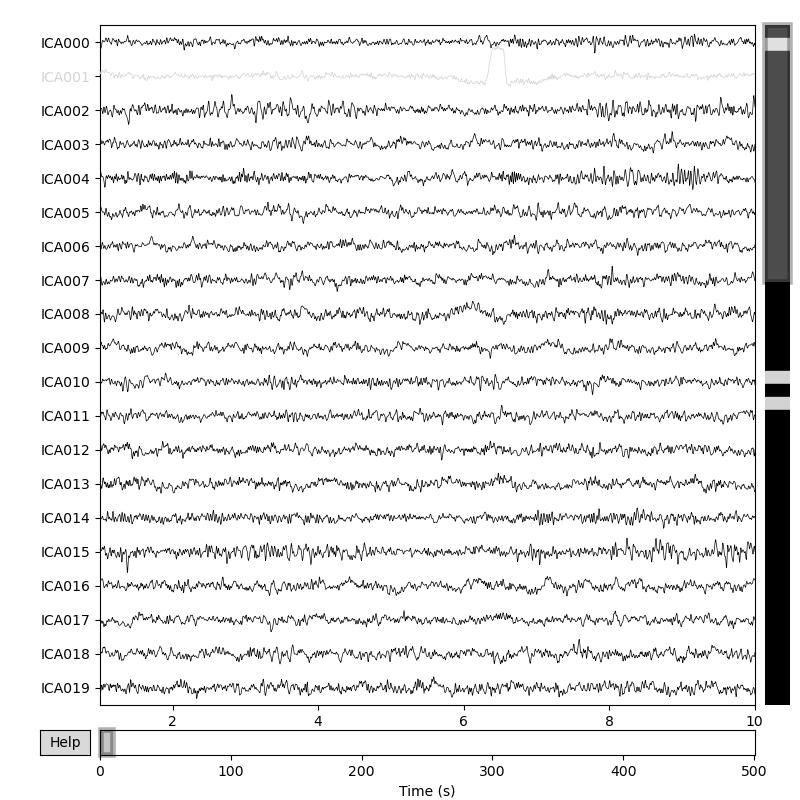

In [5]:

subjNr =1
blockNr = 1
ica_folder = 'ica_qc_blockwise2'
plt.close('all')

blockNr = blockNr -1
# subject_id = all_subjects[all_subjects.index('19880331igse')]
# subject_id = all_subjects[30]
# subject_id = all_subjects[subjNr]
subject_id = '20040630gbaf'
print(f"Subject ID: {subject_id}")

# _, icaPaths = get_outFilePaths(subject_id, out_root="/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc")
# _, icaPaths = get_outFilePaths(subject_id, out_root=f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}")
# rawFile = icaPaths[blocks[0]]['file_icaData']
# icaFile = icaPaths[blocks[0]]['file_ica']


_, icaPaths = get_blockwise_outFilePaths(subject_id, out_root=f"/home/scc_e_393956/Desktop/reabt/ncc/MEG/{ica_folder}", block_indices=[blockNr+1])
icaPaths['blocks'][blockNames[blockNr]]

rawFile = icaPaths['blocks'][blockNames[blockNr]]['file_icaData']
icaFile = icaPaths['blocks'][blockNames[blockNr]]['file_ica']

# rawFile = f'/home/scc_e_393956/Desktop/reabt/ncc/MEG/ica_qc_blockwise/step1_raw_continuous/{subject_id}_block_00_raw.fif'

raw = mne.io.read_raw_fif(rawFile, preload=False)
ica = mne.preprocessing.read_ica(icaFile)
# raw = raw.filter(l_freq = None , h_freq=40.0, n_jobs=-1)
fig = ica.plot_sources(
    raw,
    show=True,
    block=False,
	# overview_mode=False,
    start = 1,
    stop = 10,   
)


In [6]:
train_peaks, irasa_out, bad_ics  = find_train_ica(raw, ica, train_freq = 16.7, sd = 2, hmax = 1.5) #, duration=4, overlap=0.7)
print(bad_ics)
print(zscore(train_peaks['pw']))
train_peaks

trying lower sd: 1.99
trying lower sd: 1.98
trying lower sd: 1.97
trying lower sd: 1.96
trying lower sd: 1.95
trying lower sd: 1.94
trying lower sd: 1.93
trying lower sd: 1.92
trying lower sd: 1.91
trying lower sd: 1.9
trying lower sd: 1.89
trying lower sd: 1.88
trying lower sd: 1.8699999999999999
trying lower sd: 1.8599999999999999
trying lower sd: 1.8499999999999999
trying lower sd: 1.8399999999999999
trying lower sd: 1.8299999999999998
trying lower sd: 1.8199999999999998
trying lower sd: 1.8099999999999998
trying lower sd: 1.7999999999999998
trying lower sd: 1.7899999999999998
trying lower sd: 1.7799999999999998
trying lower sd: 1.7699999999999998
trying lower sd: 1.7599999999999998
trying lower sd: 1.7499999999999998
trying lower sd: 1.7399999999999998
trying lower sd: 1.7299999999999998
[30]
[-0.47294544  1.39070058 -0.91775514]


,ch_name,cf,bw,pw
0,28,16.75,1.490937,0.005976
2,47,16.50,1.425373,0.011926
3,48,16.50,1.404209,0.004556


In [7]:
raw.info


<Info | 27 non-empty values
 acq_pars: ACQactiveGround 0 ACQch.BIO001.gain 2000 ACQch.BIO001.highpass ...
 bads: []
 ch_names: EOG001, EOG002, ECG003, IASX+, IASX-, IASY+, IASY-, IASZ+, ...
 chs: 2 EOG, 1 ECG, 11 Internal Active Shielding data (Triux systems), 102 Magnetometers, 204 Gradiometers, 6 misc, 17 Stimulus, 1 System status channel information (Triux systems)
 custom_ref_applied: False
 description: TRIUX system at Salzburg-3122
 dev_head_t: MEG device -> head transform
 device_info: 4 items (dict)
 dig: 1074 items (3 Cardinal, 5 HPI, 1066 Extra)
 events: 1 item (list)
 experimenter: meg (meg)
 file_id: 4 items (dict)
 gantry_angle: 68.0
 helium_info: 2 items (dict)
 highpass: 1.0 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 hpi_subsystem: 3 items (dict)
 line_freq: 50.0
 lowpass: 40.0 Hz
 meas_date: 2026-05-20 11:27:29 UTC
 meas_id: 4 items (dict)
 nchan: 344
 proc_history: 1 item (list)
 proj_id: 1 item (ndarray)
 proj_name: aw_ncc
 projs: []
 sfreq: 200.0 Hz
 subject_info: 8 items (dict)
 utc_offset: +02:00
>

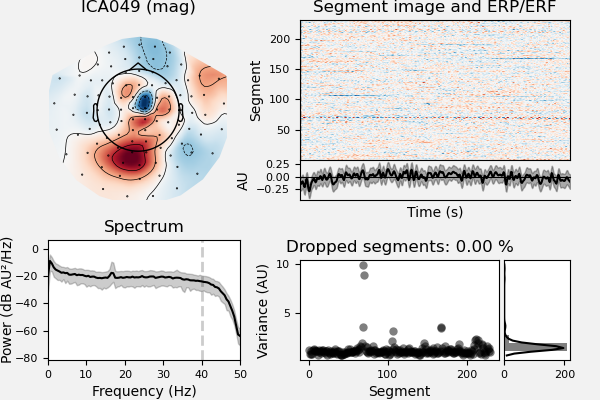

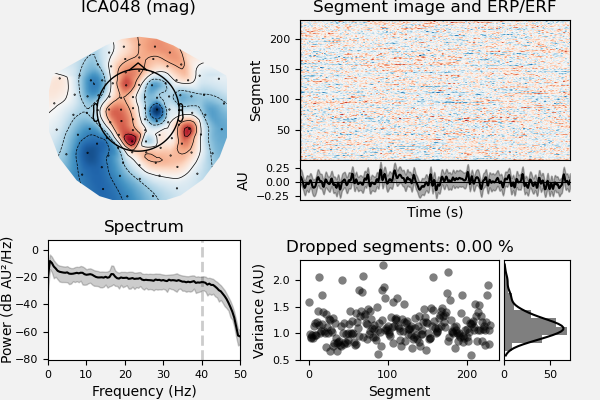

In [141]:
with mne.use_log_level('ERROR'):  # only show critical errors
	a = ica.plot_properties(
		raw, picks = [48, 49],
		figsize = (6, 4), psd_args={'method': 'welch'})

In [ ]:
comp = [35, 37, 39, 40 , 46]
ica.get_explained_variance_ratio(raw.load_data(), components = comp)

In [116]:
bad = []
if not bad:
	print(1)

1
